In [1]:
import pandas as pd
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt
import json
from pprint import pprint
import re

In [14]:
with open('data/sankt-peterburg.geojson', 'r', encoding='utf-8') as f:
    data = json.load(f)

dtp_list = data['features']
df = pd.json_normalize(dtp_list)
df.columns = df.columns.str.replace('properties.', '', regex=False)
df.columns

Index(['type', 'geometry.type', 'geometry.coordinates', 'id', 'tags', 'light',
       'point.lat', 'point.long', 'nearby', 'region', 'scheme', 'address',
       'weather', 'category', 'datetime', 'severity', 'vehicles', 'dead_count',
       'participants', 'injured_count', 'parent_region', 'road_conditions',
       'participants_count', 'participant_categories'],
      dtype='object')

In [15]:
df.head(1)

,type,geometry.type,geometry.coordinates,id,tags,light,point.lat,point.long,nearby,region,...,datetime,severity,vehicles,dead_count,participants,injured_count,parent_region,road_conditions,participants_count,participant_categories
0,Feature,Point,"[30.348841, 59.946339]",531594,[Дорожно-транспортные происшествия],"В темное время суток, освещение включено",59.946339,30.348841,"[Многоквартирные жилые дома, Нерегулируемый пе...",Центральный район,...,2023-11-04 22:15:00,Легкий,"[{'year': 2021, 'brand': 'AUDI', 'color': 'Сер...",0,[],1,Санкт-Петербург,[Мокрое],3,[Все участники]


In [5]:
df.iloc[1, :]

type                                                                Feature
geometry.type                                                         Point
geometry.coordinates                                     [30.3739, 59.9236]
id                                                                   531574
tags                                    [Дорожно-транспортные происшествия]
light                                                   Светлое время суток
point.lat                                                           59.9236
point.long                                                          30.3739
nearby                     [Внутридворовая территория, Лечебные учреждения]
region                                                    Центральный район
scheme                                                                 None
address                       г Санкт-Петербург, ул Миргородская, 3 корп. 3
weather                                                              [Ясно]
category    

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56671 entries, 0 to 56670
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   type                    56671 non-null  object 
 1   geometry.type           56671 non-null  object 
 2   geometry.coordinates    56671 non-null  object 
 3   id                      56671 non-null  int64  
 4   tags                    56671 non-null  object 
 5   light                   56671 non-null  object 
 6   point.lat               55476 non-null  float64
 7   point.long              55476 non-null  float64
 8   nearby                  56671 non-null  object 
 9   region                  56671 non-null  object 
 10  scheme                  52499 non-null  object 
 11  address                 53616 non-null  object 
 12  weather                 56671 non-null  object 
 13  category                56671 non-null  object 
 14  datetime                56671 non-null

### Таргет - Обработка severity

In [38]:
df['severity'].value_counts()

severity
Легкий         36504
Тяжёлый        18119
С погибшими     2048
Name: count, dtype: int64

In [39]:
severity_map = {
    'Легкий': 0,
    'Тяжёлый': 1,
    'С погибшими': 2
}

y = df['severity'].map(severity_map)
df = df.drop(columns=['severity'])
df.columns

Index(['type', 'geometry.type', 'geometry.coordinates', 'id', 'tags', 'light',
       'point.lat', 'point.long', 'nearby', 'region', 'scheme', 'address',
       'weather', 'category', 'datetime', 'vehicles', 'dead_count',
       'participants', 'injured_count', 'parent_region', 'road_conditions',
       'participants_count', 'participant_categories'],
      dtype='object')

## Удалим очевидно ненужные данные

Надо удалить

type, geometry.type, id, tags, address, participants, injured_count, parent_region, dead_count, participants_count, geometry.coordinates

In [8]:
df['type'].value_counts()

type
Feature    56671
Name: count, dtype: int64

In [9]:
df['geometry.type'].value_counts()

geometry.type
Point    56671
Name: count, dtype: int64

In [10]:
df['geometry.coordinates']

0        [30.348841, 59.946339]
1            [30.3739, 59.9236]
2                  [None, None]
3                  [None, None]
4            [30.3553, 59.9311]
                  ...          
56666     [30.297707, 59.90926]
56667    [30.288572, 59.921364]
56668    [30.291179, 59.933353]
56669    [30.303141, 59.931278]
56670    [30.298689, 59.920605]
Name: geometry.coordinates, Length: 56671, dtype: object

In [11]:
df['tags'].value_counts()

tags
[Дорожно-транспортные происшествия]    56671
Name: count, dtype: int64

In [12]:
df['parent_region'].value_counts()

parent_region
Санкт-Петербург    56671
Name: count, dtype: int64

In [13]:
df['dead_count'].value_counts()

dead_count
0    54623
1     1932
2       89
3       19
4        6
8        1
7        1
Name: count, dtype: int64

In [14]:
cols_to_drop = [
    'type', 
    'geometry.type', 
    'geometry.coordinates', # Координаты у нас уже есть в point.lat/long
    'id', 
    'tags', 
    'address', 
    # 'participants', 
    'injured_count',        # Утечка!
    'dead_count',           # Утечка!
    # 'participants_count',   # Потенциальная утечка
    'parent_region'         # Константа
]

df = df.drop(columns=cols_to_drop)

print(f"Размер датафрейма: {df.shape}")
print("Оставшиеся колонки:")
print(df.columns.tolist())

Размер датафрейма: (56671, 12)
Оставшиеся колонки:
['light', 'point.lat', 'point.long', 'nearby', 'region', 'scheme', 'weather', 'category', 'datetime', 'vehicles', 'road_conditions', 'participant_categories']


## Другие столбцы

### Обработка освещения

In [15]:
df['light'].value_counts()

light
Светлое время суток                            36779
В темное время суток, освещение включено       18268
Сумерки                                         1045
В темное время суток, освещение отсутствует      415
В темное время суток, освещение не включено      163
Не установлено                                     1
Name: count, dtype: int64

In [16]:
def map_light(val):
    if pd.isna(val):
        return 'unknown'
    
    val = str(val).lower()
    
    if 'светлое время' in val:
        return 'day'
    
    if 'освещение включено' in val:
        return 'night_light'
    
    if 'освещение отсутствует' in val or 'освещение не включено' in val:
        return 'night_dark'
    
    if 'сумерки' in val:
        return 'twilight'
        
    return 'day' 

df['light_cat'] = df['light'].apply(map_light)
df = df.drop(columns=['light'])

In [17]:
df['light_cat'].value_counts()

light_cat
day            36780
night_light    18268
twilight        1045
night_dark       578
Name: count, dtype: int64

### Обработка времени

In [18]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek

### Обработка nearby

In [19]:
list(df['nearby'].explode().value_counts().keys())

['Многоквартирные жилые дома',
 'Регулируемый пешеходный переход',
 'Регулируемый перекресток',
 'Остановка общественного транспорта',
 'Нерегулируемый пешеходный переход',
 'Регулируемый перекрёсток',
 'Крупный торговый объект (являющийся объектом массового тяготения пешеходов и (или) транспорта)',
 'Нерегулируемый перекрёсток неравнозначных улиц (дорог)',
 'Внутридворовая территория',
 'Выезд с прилегающей территории',
 'Административные здания',
 'АЗС',
 'Нерегулируемый перекрёсток',
 'Остановка трамвая',
 'Производственное предприятие',
 'Тротуар, пешеходная дорожка',
 'Автостоянка (отделенная от проезжей части)',
 'Школа либо иная детская (в т.ч. дошкольная) организация',
 'Жилые дома индивидуальной застройки',
 'Мост, эстакада, путепровод',
 'Нерегулируемый перекрёсток равнозначных улиц (дорог)',
 'Медицинские (лечебные) организации',
 'Мост',
 'Зоны отдыха',
 'Эстакада, путепровод',
 'Иной объект',
 'Одиночный торговый объект, являющийся местом притяжения транспорта и (или) пеше

In [20]:
def normalize_category_name(s: str) -> str:
    """
    Нормализует название категории по строгим правилам:
    - нижний регистр
    - ё → е
    - удалить всё, кроме букв, цифр и пробелов
    - пробелы заменить на _
    """
    s = s.lower()
    s = s.replace('ё', 'е')  # замена ё на е
    # Оставить только буквы, цифры и пробелы
    s = re.sub(r'[^а-яa-z0-9\s]', '', s)
    # Заменить один или несколько пробелов на _
    s = re.sub(r'\s+', '_', s)
    return s.strip('_')

In [21]:
def classify_optimized(s: str) -> str:
    s = s.lower()
    
    # 1. Жилая зона (дома + дворы)
    if any(word in s for word in ["жил", "многоквартирн", "индивидуальной_застройк", "внутридворов"]):
        return "residential"
    
    # 2. Пешеходная инфраструктура (все переходы + тротуары)
    if any(word in s for word in [
        "пешеходный_переход", "надземн", "подземн", 
        "тротуар", "пешеходная_дорожка", "пешеходная_зона"
    ]):
        return "pedestrian_infrastructure"
    
    # 3. Дорожные узлы (перекрёстки + весовой контроль)
    if any(word in s for word in [
        "перекресток", "перекрёсток", "кругов", "выезд_с_прилегающей",
        "весового_контроля", "равнозначн", "неравнозначн"
    ]):
        return "road_junctions"
    
    # 4. Образование (только учреждения, без переходов!)
    if any(word in s for word in [
        "школа", "дошкольн", "детск", "образовательн", 
        "университет", "колледж", "училищ"
    ]) and "переход" not in s:  # Ключевое условие!
        return "education"
    
    # 5. Коммерция
    if any(word in s for word in [
        "торгов", "азс", "заправ", "магазин", "кафе", "ресторан",
        "общественного_питания", "массового_тяготени", "место_притяжения"
    ]):
        return "commercial"
    
    # 6. Общественный транспорт
    if any(word in s for word in [
        "остановка", "трамвай", "автобус", "маршрутн", 
        "автостанц", "автовокзал", "метро"
    ]):
        return "public_transport"
    
    # 7. Ж/д
    if any(word in s for word in ["жд", "железн", "вокзал_жд", "станци_жд", "переезд_жд"]):
        return "railway"
    
    # 8. Транспортные хабы (аэропорты, порты)
    if any(word in s for word in ["аэропорт", "порт", "пристан", "морск", "речн"]):
        return "transport_hubs"
    
    # 9. Административные
    if any(word in s for word in ["административн", "мвд", "дпс", "полиц", "кпм"]):
        return "administrative"
    
    # 10. Медицина
    if any(word in s for word in ["медицинск", "лечебн", "больниц", "поликлин"]):
        return "healthcare"
    
    # 11. Дорожные объекты
    if any(word in s for word in ["мост", "эстакад", "путепровод", "тоннел", "подход_к_мосту"]):
        return "road_objects"
    
    # 12. Прочее (промышленность, спорт, религия, кладбища)
    return "other"

In [22]:
# Получаем уникальные нормализованные строки
raw_unique = df['nearby'].explode().dropna().unique()
normalized_unique = [normalize_category_name(str(x)) for x in raw_unique]

# Вспомогательная функция для любого классификатора
def build_category_mapping_with_func(categories, classifier_func):
    from collections import defaultdict
    mapping = defaultdict(set)
    for cat in categories:
        label = classifier_func(cat)
        mapping[label].add(cat)
    return dict(mapping)

# Строим новый mapping
broad_mapping = build_category_mapping_with_func(normalized_unique, classify_optimized)

In [23]:
pprint(broad_mapping)

{'administrative': {'административные_здания',
                    'сп_дпс_кпм',
                    'территориальное_подразделение_мвд_россии_либо_его_структурное_подразделение'},
 'commercial': {'азс',
                'крупный_торговый_объект_являющийся_объектом_массового_тяготения_пешеходов_и_или_транспорта',
                'объект_торговли_общественного_питания_на_автодороге_вне_нп',
                'одиночный_торговый_объект_являющийся_местом_притяжения_транспорта_и_или_пешеходов'},
 'education': {'иная_образовательная_организация',
               'иное_образовательное_учреждение',
               'школа_либо_иная_детская_в_тч_дошкольная_организация',
               'школа_либо_иное_детское_в_тч_дошкольное_учреждение'},
 'healthcare': {'медицинские_лечебные_организации'},
 'other': {'автостоянка_не_отделенная_от_проезжей_части',
           'автостоянка_отделенная_от_проезжей_части',
           'зоны_отдыха',
           'иной_объект',
           'кладбище',
           'объект_здани

In [24]:
def process_nearby_flags(nearby_list):
    flags = {
        'near_residential': 0,
        'near_intersection': 0,
        'near_pedestrian': 0,
        'near_public_transport': 0,
        'near_school': 0,
        'near_mall': 0,
        'near_dangerous': 0 # Мосты, тоннели, жд
    }
    
    if not isinstance(nearby_list, list):
        return pd.Series(flags)
        
    text = " ".join(str(x).lower() for x in nearby_list)
    
    if any(x in text for x in ['жилые', 'жилой', 'дворов']):
        flags['near_residential'] = 1
        
    if 'перекресток' in text or 'перекрёсток' in text or 'круговое' in text or 'пересечение' in text:
        flags['near_intersection'] = 1
        
    if 'пешеход' in text or 'тротуар' in text:
        flags['near_pedestrian'] = 1
        
    if 'остановка' in text or 'вокзал' in text:
        flags['near_public_transport'] = 1
        
    if 'школа' in text or 'детская' in text or 'детское' in text:
        flags['near_school'] = 1
        
    if 'торговый' in text or 'магазин' in text or 'азс' in text or 'парковка' in text or 'стоянка' in text:
        flags['near_mall'] = 1
        
    if any(x in text for x in ['мост', 'эстакада', 'путепровод', 'тоннель', 'ж/д', 'железнодорож']):
        flags['near_dangerous'] = 1
        
    return pd.Series(flags)

In [25]:
nearby_features = df['nearby'].apply(process_nearby_flags)
df = pd.concat([df, nearby_features], axis=1)
df = df.drop(columns=['nearby'])
df.columns

Index(['point.lat', 'point.long', 'region', 'scheme', 'weather', 'category',
       'datetime', 'vehicles', 'road_conditions', 'participant_categories',
       'light_cat', 'hour', 'year', 'month', 'day_of_week', 'near_residential',
       'near_intersection', 'near_pedestrian', 'near_public_transport',
       'near_school', 'near_mall', 'near_dangerous'],
      dtype='object')

### Обработка region

In [26]:
df['region'].value_counts()

region
Выборгский район           5766
Невский район              5165
Приморский район           4803
Московский район           4589
Калининский район          4437
Красногвардейский район    3947
Красносельский район       3816
Центральный район          3771
Кировский район            3371
Фрунзенский район          3278
Пушкинский район           2515
Адмиралтейский район       2365
Василеостровский район     1963
Петроградский район        1939
Колпинский район           1687
Курортный район            1604
Петродворцовый район       1293
Кронштадтский район         362
Name: count, dtype: int64

### Обработка кода аварии

In [27]:
df['scheme']

0         050
1        None
2         740
3         740
4         950
         ... 
56666     500
56667     920
56668     720
56669     730
56670     500
Name: scheme, Length: 56671, dtype: object

In [28]:
df['scheme'] = df['scheme'].fillna('000').astype(str)
df['scheme'] = df['scheme'].apply(lambda x: x.split('.')[0])

In [29]:
df['scheme'].value_counts()

scheme
070    6280
300    4919
820    4749
740    4355
000    4172
       ... 
230      10
980      10
970       8
630       7
620       4
Name: count, Length: 61, dtype: int64

### Обработка категории аварии

In [42]:
df['category'].value_counts()

category
Столкновение                                                                                                 22404
Наезд на пешехода                                                                                            20956
Падение пассажира                                                                                             3732
Наезд на велосипедиста                                                                                        3085
Наезд на препятствие                                                                                          2945
Наезд на стоящее ТС                                                                                           2296
Опрокидывание                                                                                                  508
Съезд с дороги                                                                                                 441
Иной вид ДТП                                                           

In [32]:
def clean_category(val):
    val = str(val).lower()
    
    if 'столкновение' in val:
        return 'collision'
    
    if 'пешеход' in val or 'наезд на лицо' in val:
        return 'pedestrian'
    
    if 'велосипед' in val:
        return 'cyclist'
    
    if 'пассажир' in val:
        return 'passenger'
    
    if 'препятств' in val or 'стоящее тс' in val:
        return 'static_obstacle'
    
    if 'опрокидывание' in val or 'съезд' in val:
        return 'loss_control'
    
    return 'other'

df['category_cleaned'] = df['category'].apply(clean_category)
df = df.drop(columns=['category'])
df['category_cleaned'].value_counts()

category_cleaned
collision          22404
pedestrian         21027
static_obstacle     5254
passenger           3732
cyclist             3085
loss_control         949
other                220
Name: count, dtype: int64

### Обработка погоды

In [32]:
df['weather'][0]

['Пасмурно']

In [33]:
df['weather'].explode().value_counts()

weather
Ясно                     26447
Пасмурно                 25547
Дождь                     3674
Снегопад                  1422
Туман                       42
Метель                      16
Температура выше +30С        8
Ураганный ветер              3
Name: count, dtype: int64

In [34]:
def process_weather_flags(w_list):
    flags = {
        'weather_clear': 0,    # Ясно
        'weather_overcast': 0, # Пасмурно (вкл. туман)
        'weather_rain': 0,     # Дождь (вкл. ураган)
        'weather_snow': 0      # Снег (вкл. метель)
    }
    
    if not isinstance(w_list, list):
        return pd.Series(flags)
    
    text = " ".join(str(x).lower() for x in w_list)
    
    if 'снег' in text or 'метель' in text:
        flags['weather_snow'] = 1
        
    if 'дождь' in text or 'ураган' in text:
        flags['weather_rain'] = 1
        
    if 'пасмурно' in text or 'туман' in text:
        flags['weather_overcast'] = 1
        
    if 'ясно' in text or 'выше +30' in text:
        flags['weather_clear'] = 1
        
    return pd.Series(flags)

In [ ]:
weather_features = df['weather'].apply(process_weather_flags)
df = pd.concat([df, weather_features], axis=1)
df = df.drop(columns=['weather'])
df.columns

### Обработка road_conditions

In [ ]:
df['road_conditions'].explode().value_counts()

In [ ]:
def process_road_conditions(cond_list):
    flags = {
        'road_wet': 0,
        'road_snow_ice': 0,
        'road_dry': 0,
        'road_defect': 0
    }
    
    if not isinstance(cond_list, list):
        return pd.Series(flags)
    
    text = " ".join(str(x).lower() for x in cond_list)
    
    if any(x in text for x in ['снег', 'снеж', 'лед', 'гололед', 'зимн', 'скользк', 'обработанное']):
        flags['road_snow_ice'] = 1
        
    if any(x in text for x in ['мокр', 'залит', 'гряз', 'пыль']):
        flags['road_wet'] = 1
        
    if 'сухое' in text:
        flags['road_dry'] = 1
        
    bad_road_keywords = [
        'отсутствие', 'плохая', 'недостат', 'дефект', 'неровн', 
        'неисправн', 'несоответствие', 'нарушени', 'сужение', 'низкие сцепные'
    ]
    if any(x in text for x in bad_road_keywords):
        flags['road_defect'] = 1
        
    return pd.Series(flags)

In [ ]:
road_features = df['road_conditions'].apply(process_road_conditions)
df = pd.concat([df, road_features], axis=1)
df = df.drop(columns=['road_conditions'])
df.columns

### Обработка participant_categories

In [16]:
df['participant_categories'].explode().value_counts()

participant_categories
Все участники     56671
Пешеходы          21693
Мотоциклисты       3377
Велосипедисты      3232
Общ. транспорт     1310
Name: count, dtype: int64

In [ ]:
df['has_pedestrian'] = df['participant_categories'].apply(
    lambda x: 1 if isinstance(x, list) and 'Пешеходы' in x else 0
)
df = df.drop(columns=['participant_categories'])
df.columns

### Обработка participants_count

In [74]:
df['participants_count'].mean()

np.float64(2.4067512484339435)

## Обработка participants

In [12]:
df['participants'][1511]

[{'role': 'Пешеход',
  'gender': 'Женский',
  'violations': [],
  'health_status': 'Раненый, находящийся (находившийся)  на амбулаторном лечении, либо которому по характеру полученных травм обозначена необходимость амбулаторного лечения (вне зависимости от его фактического прохождения)'}]

In [77]:
all_roles = []

for part_list in df['participants']:
    if isinstance(part_list, list):
        for participant in part_list:
            if isinstance(participant, dict) and 'role' in participant:
                role = participant['role']
                if pd.notna(role):  # исключаем NaN/None
                    all_roles.append(role)

unique_roles = sorted(set(all_roles))
unique_roles

['Иной участник',
 'Лицо, осуществляющее торговлю (иную деятельность) на проезжей части (обочине и т.д.)',
 'Лицо, осуществляющее умышленное перекрытие проезжей части',
 'Пешеход',
 'Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира',
 'Работник дорожной организации, осуществляющий работы на проезжей части (обочине и т.д.)',
 'Работник иных организаций (коммунальных служб, электросетей, водоканала и т.д.), осуществляющий работы на проезжей части (обочине и т.д.)',
 'Сотрудник ДПС (ГИБДД), выполняющий служебные обязанности на проезжей части (обочине и т.д.)',
 'Сотрудник полиции (кроме ГИБДД), сотрудник (военнослужащий) Росгвардии, Минобороны, ФСБ, ФСО, МЧС и т.д., выполняющий служебные обязанности на проезжей части (обочине и т.д.)']

In [80]:
all_roles = []

for part_list in df['participants']:
    if isinstance(part_list, list):
        for participant in part_list:
            if isinstance(participant, dict) and 'gender' in participant:
                role = participant['gender']
                if pd.notna(role):
                    all_roles.append(role)

unique_roles = sorted(set(all_roles))
unique_roles

['Женский', 'Мужской']

In [20]:
from collections import Counter

all_violations = []

for part_list in df['participants']:
    if isinstance(part_list, list):
        for participant in part_list:
            if isinstance(participant, dict) and 'violations' in participant:
                violations = participant['violations']
                if isinstance(violations, list):
                    for v in violations:
                        if pd.notna(v) and v != '':
                            all_violations.append(v)

# Считаем частоту каждого нарушения
violation_counts = Counter(all_violations)

# Уникальные нарушения (по алфавиту)
unique_violations = sorted(violation_counts.keys())
violation_counts

Counter({'Переход через проезжую часть вне пешеходного перехода в зоне его видимости либо при наличии в непосредственной близости подземного (надземного) пешеходного перехода': 3319,
         'Неподчинение сигналам регулирования': 1686,
         'Переход через проезжую часть в неустановленном месте (при наличии в зоне видимости перекрёстка)': 958,
         'Иные нарушения': 532,
         'Неожиданный выход из-за стоящего ТС': 419,
         'Нахождение на проезжей части без цели её перехода': 335,
         'Неожиданный выход из-за ТС': 238,
         'Пешеход в состоянии алкогольного опьянения': 170,
         'Переход проезжей части в запрещённом месте (оборудованном пешеходными  ограждениями)': 167,
         'Движение вдоль проезжей части при наличии и удовлетворительном состоянии тротуара': 59,
         'Передвижение по проезжей части на скейтборде (роликовых коньках и т.д.)': 56,
         'Ходьба вдоль проезжей части при наличии и удовлетворительном состоянии тротуара': 41,
         '

## Обработка vehicles

In [22]:
from collections import defaultdict

In [23]:
df['vehicles'][0]

[{'year': 2021,
  'brand': 'AUDI',
  'color': 'Серый',
  'model': 'А6',
  'category': 'С-класс (малый средний, компактный) до 4,3 м',
  'participants': [{'role': 'Пассажир',
    'gender': 'Женский',
    'violations': [],
    'health_status': 'Раненый, находящийся (находившийся) на амбулаторном лечении, либо в условиях дневного стационара',
    'years_of_driving_experience': None},
   {'role': 'Водитель',
    'gender': 'Мужской',
    'violations': [],
    'health_status': 'Не пострадал',
    'years_of_driving_experience': 17}]},
 {'year': None,
  'brand': None,
  'color': None,
  'model': None,
  'category': 'С-класс (малый средний, компактный) до 4,3 м',
  'participants': [{'role': 'Водитель',
    'gender': None,
    'violations': ['Оставление места ДТП', 'Неправильный выбор дистанции'],
    'health_status': 'Не пострадал',
    'years_of_driving_experience': None}]}]

In [24]:
all_keys = set()
for vehicles_list in df['vehicles']:
    if isinstance(vehicles_list, list):  # на случай пропусков или несписков
        for vehicle in vehicles_list:
            if isinstance(vehicle, dict):
                all_keys.update(vehicle.keys())
all_keys

{'brand', 'category', 'color', 'model', 'participants', 'year'}

### Обработка category

In [27]:
category_counter = defaultdict(int)
for dtp in df['vehicles']:
    for vehicle in dtp:
        category_counter[vehicle['category']] += 1

In [55]:
# category_counter

In [ ]:
def get_super_category(cat_name):
    if not isinstance(cat_name, str):
        return 'unknown'
    
    c = cat_name.lower()
    
    if any(x in c for x in ['мото', 'вело', 'мопед', 'сим', 'квадро', 'трицикл', 'скутер', 'персональное электрическое средство передвижения малой мощности']):
        return 'moto_bike'
    
    if any(x in c for x in [
        'автобус', 'трамва', 'троллейбус', 'электробус',
        'одноэтажн', 'двухэтажн',
        'одноярусн', 'двухярусн',  # <-- добавлено
        'пассажир'
    ]):
        return 'public'
    
    if any(x in c for x in ['грузов', 'фургон', 'тягач', 'самосвал', 'цистерн', 'шасси', 'рефрижератор', 'камаз', 'маз']):
        return 'truck'
    
    if any(x in c for x in ['трактор', 'спец', 'экскаватор', 'бульдозер', 'погрузчик', 'кран', 'дорожн', 'уборочн', 'пожарн', 'скорая', 'медицин']):
        return 'special'
    
    if 'класс' in c or 'легков' in c or 'минивэн' in c:
        return 'car'

    return 'other'

In [ ]:
def extract_vehicle_features_advanced(vehicles_list):
    feats = {
        'cnt_car': 0,
        'cnt_truck': 0,
        'cnt_public': 0,
        'cnt_moto_bike': 0,
        'cnt_special': 0,
        'cnt_total': 0
    }

    if not isinstance(vehicles_list, list):
        return pd.Series(feats)
    
    feats['cnt_total'] = len(vehicles_list)
    
    for v in vehicles_list:
        raw_cat = v.get('category', '')

        super_cat = get_super_category(raw_cat)
        if super_cat == 'car':
            feats['cnt_car'] += 1
        elif super_cat == 'truck':
            feats['cnt_truck'] += 1
        elif super_cat == 'public':
            feats['cnt_public'] += 1
        elif super_cat == 'moto_bike':
            feats['cnt_moto_bike'] += 1
        elif super_cat == 'special':
            feats['cnt_special'] += 1
            
    return pd.Series(feats)

In [ ]:
df_vehicles = df['vehicles'].apply(extract_vehicle_features_advanced)
df = pd.concat([df, df_vehicles], axis=1)
df.columns

### Обработка brand

In [49]:
from collections import Counter

In [50]:
unic_brand = Counter()
for vehicles in df['vehicles']:
    for car in vehicles:
        unic_brand[car['brand']] += 1
len(unic_brand)

273

In [52]:
# unic_brand

In [ ]:
def get_brand_category(brand_name):
    if pd.isna(brand_name) or brand_name is None:
        return 'unknown'
    
    b = str(brand_name).upper().strip()
    
    # 1. Отечественные
    if b in {'ВАЗ', 'ГАЗ', 'УАЗ', 'LADA', 'ИЖ', 'МОСКВИЧ', 'ЗАЗ', 'ТАГАЗ (TAGAZ)', 
             'КАМАЗ', 'МАЗ', 'ПАЗ', 'ЛИАЗ', 'НЕФАЗ', 'КРАЗ', 'УРАЛ', 'ЗИЛ', 'КАВЗ'}:
        return 'ru_cis'

    # 2. Премиум
    if b in {'MERCEDES', 'BMW', 'AUDI', 'LEXUS', 'VOLVO', 'LAND ROVER', 'PORSCHE', 
             'INFINITI', 'JAGUAR', 'CADILLAC', 'MINI', 'GENESIS', 'TESLA', 'BENTLEY'}:
        return 'premium'

    # 3. Китай
    if b in {'CHERY', 'GEELY', 'HAVAL', 'EXEED', 'OMODA', 'LIFAN', 'GREAT WALL', 
             'CHANGAN', 'FAW', 'JAC', 'TANK', 'VOYAH', 'BYD', 'DONGFENG', 'FOTON', 'SITRAK', 'SHACMAN'}:
        return 'chinese'

    # 4. Коммерческие/Грузовые
    if b in {'MAN', 'SCANIA', 'DAF', 'ISUZU', 'IVECO', 'FREIGHTLINER', 'SETRA', 
             'NEOPLAN', 'HIGER', 'KING LONG', 'YUTONG', 'VOLGABUS'}:
        return 'commercial'

    # 5. Мото бренды
    if b in {'YAMAHA', 'KAWASAKI', 'HARLEY-DAVIDSON', 'DUCATI', 'KTM', 'TRIUMPH', 'BAJAJ'}:
        return 'moto'

    # 6. Масс-маркет (все остальные популярные иномарки)
    if b in {'HYUNDAI', 'KIA', 'VOLKSWAGEN', 'RENAULT', 'TOYOTA', 'NISSAN', 'FORD', 
             'SKODA', 'CHEVROLET', 'MITSUBISHI', 'OPEL', 'HONDA', 'MAZDA', 'SUZUKI', 
             'PEUGEOT', 'CITROEN', 'DAEWOO', 'SUBARU', 'FIAT', 'SSANGYONG'}:
        return 'foreign_mass'

    return 'other'

In [ ]:
def count_brands_in_accident(vehicles_list):
    counts = {
        'brand_ru_cis': 0,
        'brand_premium': 0,
        'brand_foreign_mass': 0,
        'brand_chinese': 0,
        'brand_commercial': 0,
        'brand_moto': 0,
        'brand_unknown': 0
    }
    
    if not isinstance(vehicles_list, list) or len(vehicles_list) == 0:
        return pd.Series(counts)
    
    for v in vehicles_list:
        brand_name = v.get('brand')
        category = get_brand_category(brand_name)
        
        key = f'brand_{category}'
        
        if key in counts:
            counts[key] += 1
        elif category == 'other':
            counts['brand_unknown'] += 1
            
    return pd.Series(counts)

In [ ]:
brand_counts_df = df['vehicles'].apply(count_brands_in_accident)
df = pd.concat([df, brand_counts_df], axis=1)
df.columns

### Обработка года

In [ ]:
list(df['year'].unique())

In [ ]:
def calculate_age_stats(row):
    try:
        crash_year = row['datetime'].year
    except:
        crash_year = 2024
        
    vehicles_list = row['vehicles']
    ages = []

    # Если списка нет
    if not isinstance(vehicles_list, list) or len(vehicles_list) == 0:
        return pd.Series({'mean_age': np.nan, 'max_age': np.nan})

    for v in vehicles_list:
        prod_year = v.get('year')
        if prod_year is not None and isinstance(prod_year, (int, float)):
            if 1950 < prod_year <= crash_year:
                age = crash_year - prod_year
                ages.append(age)
    
    # Если список возрастов пуст (все года были None)
    if not ages:
        return pd.Series({'mean_age': np.nan, 'max_age': np.nan})
        
    return pd.Series({
        'mean_age': round(np.mean(ages), 1),
        'max_age': int(np.max(ages))
    })

df_ages = df.apply(calculate_age_stats, axis=1)

In [ ]:
df = pd.concat([df, df_ages], axis=1)
df.iloc[1][['datetime', 'vehicles', 'mean_age', 'max_age']]

In [ ]:
df.columns

### Обработка цвета

In [53]:
uniq_color = Counter()
for vehicles in df['vehicles']:
    for car in vehicles:
        uniq_color[car['color']] += 1
len(uniq_color)

14

In [54]:
uniq_color

Counter({'Белый': 20781,
         'Черный': 16115,
         'Иные цвета': 13943,
         'Серый': 12425,
         'Синий': 8171,
         'Красный': 5631,
         None: 4013,
         'Коричневый': 2648,
         'Зеленый': 2344,
         'Желтый': 1570,
         'Многоцветный': 1417,
         'Оранжевый': 922,
         'Фиолетовый': 434,
         'Не заполнено': 378})

In [ ]:
def classify_color(color_name):
    if pd.isna(color_name) or color_name is None:
        return 'unknown'
    
    c = str(color_name).lower().strip()
    
    # Группа "Плохо видно" (Темные / Сливаются с дорогой)
    if c in {'черный', 'серый', 'синий', 'коричневый', 'зеленый', 'фиолетовый', 'темно-синий'}:
        return 'low_vis'
    
    # Группа "Хорошо видно" (Яркие / Контрастные)
    if c in {'белый', 'желтый', 'оранжевый', 'красный'}:
        return 'high_vis'
        
    return 'other'

def count_colors(vehicles_list):
    counts = {
        'cnt_color_low_vis': 0,
        'cnt_color_high_vis': 0,
        'cnt_color_other': 0
    }
    
    if not isinstance(vehicles_list, list):
        return pd.Series(counts)
        
    for v in vehicles_list:
        color = v.get('color')
        cat = classify_color(color)
        
        if cat == 'low_vis':
            counts['cnt_color_low_vis'] += 1
        elif cat == 'high_vis':
            counts['cnt_color_high_vis'] += 1
        else:
            counts['cnt_color_other'] += 1
            
    return pd.Series(counts)

In [ ]:
color_features = df['vehicles'].apply(count_colors)
df = pd.concat([df, color_features], axis=1)
df.columns

### Обработка participants

In [58]:
for vehicles in df['vehicles'][:5]:
    for car in vehicles:
        for participant in car['participants']:
            pprint(participant)

{'gender': 'Женский',
 'health_status': 'Раненый, находящийся (находившийся) на амбулаторном '
                  'лечении, либо в условиях дневного стационара',
 'role': 'Пассажир',
 'violations': [],
 'years_of_driving_experience': None}
{'gender': 'Мужской',
 'health_status': 'Не пострадал',
 'role': 'Водитель',
 'violations': [],
 'years_of_driving_experience': 17}
{'gender': None,
 'health_status': 'Не пострадал',
 'role': 'Водитель',
 'violations': ['Оставление места ДТП', 'Неправильный выбор дистанции'],
 'years_of_driving_experience': None}
{'gender': 'Мужской',
 'health_status': 'Не пострадал',
 'role': 'Водитель',
 'violations': ['Несоответствие скорости конкретным условиям движения'],
 'years_of_driving_experience': 8}
{'gender': 'Женский',
 'health_status': 'Раненый, находящийся (находившийся)  на амбулаторном '
                  'лечении, либо которому по характеру полученных травм '
                  'обозначена необходимость амбулаторного лечения (вне '
                  

#### Обработка health_status

надо подумать, наверно его можно сделать таргетом

In [29]:
unic_health_status = Counter()
for vehicles in df['vehicles']:
    for car in vehicles:
        for participant in car['participants']:
            unic_health_status[participant['health_status']] += 1
# unic_health_status

#### Обработка гендера

In [ ]:
def count_gender_roles(vehicles_list):
    stats = {
        'cnt_drivers_male': 0,
        'cnt_drivers_female': 0,
        'cnt_passengers_male': 0,
        'cnt_passengers_female': 0
    }
    
    if not isinstance(vehicles_list, list):
        return pd.Series(stats)
    
    for v in vehicles_list:
        participants = v.get('participants', [])
        
        if not isinstance(participants, list):
            continue
            
        for p in participants:
            gender = p.get('gender')
            role = p.get('role')
            
            if not gender:
                continue
                
            if gender == 'Мужской':
                if role == 'Водитель':
                    stats['cnt_drivers_male'] += 1
                else:
                    stats['cnt_passengers_male'] += 1
                    
            elif gender == 'Женский':
                if role == 'Водитель':
                    stats['cnt_drivers_female'] += 1
                else:
                    stats['cnt_passengers_female'] += 1
                    
    return pd.Series(stats)

In [ ]:
gender_features = df['vehicles'].apply(count_gender_roles)
df = pd.concat([df, gender_features], axis=1)
df.columns

In [ ]:
df[['cnt_drivers_male', 'cnt_drivers_female', 'cnt_passengers_male', 'cnt_passengers_female']].head()

#### Обработка стажа вождения

In [ ]:
def get_experience_stats(vehicles_list):
    driver_exps = []
    
    if not isinstance(vehicles_list, list):
        return pd.Series({'min_driving_exp': np.nan, 'mean_driving_exp': np.nan})

    for v in vehicles_list:
        participants = v.get('participants', [])
        if not isinstance(participants, list):
            continue
            
        for p in participants:
            if p.get('role') == 'Водитель':
                exp = p.get('years_of_driving_experience')
                
                if exp is not None and isinstance(exp, (int, float)):
                    driver_exps.append(exp)
    
    if not driver_exps:
        return pd.Series({'min_driving_exp': np.nan, 'mean_driving_exp': np.nan})
    
    return pd.Series({
        'min_driving_exp': np.min(driver_exps),
        'mean_driving_exp': round(np.mean(driver_exps), 1)
    })

In [ ]:
exp_features = df['vehicles'].apply(get_experience_stats)
df = pd.concat([df, exp_features], axis=1)
df.columns

In [ ]:
df[['min_driving_exp', 'mean_driving_exp']].sample(5)

#### Обработка нарушений

In [62]:
unic_violations = Counter()
for vehicles in df['vehicles']:
    for car in vehicles:
        for participant in car['participants']:
            for violation in participant['violations']:
                unic_violations[violation] += 1
len(unic_violations)

99

In [63]:
unic_violations

Counter({'Несоблюдение очередности проезда': 8277,
         'Нарушение правил проезда пешеходного перехода': 7335,
         'Оставление места ДТП': 6919,
         'Неправильный выбор дистанции': 6375,
         'Несоблюдение требований ОСАГО': 6050,
         'Несоответствие скорости конкретным условиям движения': 4095,
         'Другие нарушения ПДД водителем': 4082,
         'Нарушение правил расположения ТС на проезжей части': 3477,
         'Нарушение правил перестроения': 2576,
         'Нарушение требований сигналов светофора': 2468,
         'Несоблюдение очередности проезда перекрестков': 2454,
         'Нарушение правил пользования общественным транспортом': 1947,
         'Несоблюдение бокового интервала': 1856,
         'Несоблюдение условий, разрешающих движение транспорта задним ходом': 1552,
         'Иные нарушения': 1452,
         'Управление ТС в состоянии алкогольного опьянения': 1390,
         'Выезд на полосу встречного движения': 1307,
         'Управление ТС лицом, 

In [ ]:
def check_violations_extended(vehicles_list):
    flags = {
        # Группа 1: Состояние водителя (Human Factor)
        'flag_drunk': 0,       # Алкоголь/Наркотики
        'flag_no_license': 0,  # Без прав
        'flag_flee': 0,        # Скрылся
        
        # Группа 2: Механика удара (Physics)
        'flag_speed': 0,       # Скорость (Кинетическая энергия высокая)
        'flag_vstrechka': 0,   # Встречка (Лобовое столкновение, очень опасно)
        'flag_intersection': 0,# Перекресток/Светофор (Боковой удар)
        'flag_distance': 0,    # Дистанция (Удар сзади/Попутный - обычно менее опасно)
        
        # Группа 3: Жертвы / Уязвимость
        'flag_pedestrian_fault': 0, # Вина пешехода (риск только для пешехода)
        'flag_safety_neglect': 0    # Ремни/Шлемы/Детские кресла (Критично для выживания)
    }
    
    if not isinstance(vehicles_list, list):
        return pd.Series(flags)

    all_violations = []
    for v in vehicles_list:
        for p in v.get('participants', []):
            viols = p.get('violations', [])
            if isinstance(viols, list):
                all_violations.extend([str(x).lower() for x in viols])
    
    for v_text in all_violations:
        # --- ГРУППА 1 ---
        if any(x in v_text for x in ['алкоголь', 'наркоти', 'опьянени', 'отказ от', 'одурманива']):
            flags['flag_drunk'] = 1
        if any(x in v_text for x in ['не имеющим права', 'лишенным', 'без права']):
            flags['flag_no_license'] = 1
        if 'оставление места' in v_text:
            flags['flag_flee'] = 1

        # --- ГРУППА 2 ---
        if 'скорост' in v_text:
            flags['flag_speed'] = 1
        if any(x in v_text for x in ['встречн', 'обгон']):
            flags['flag_vstrechka'] = 1
        if any(x in v_text for x in ['очередност', 'светофор', 'знак', 'перекрест', 'преимуществ']):
            # Исключаем пешеходов, чтобы не дублировать
            if 'пешеход' not in v_text:
                flags['flag_intersection'] = 1
        if any(x in v_text for x in ['дистанци', 'интервал', 'задним ходом']):
            flags['flag_distance'] = 1

        # --- ГРУППА 3 ---
        if any(x in v_text for x in ['пешеход', 'велосипед', 'неожиданный выход']):
            # Только если вина самого пешехода (не водителя)
            if 'непредоставление' not in v_text: 
                flags['flag_pedestrian_fault'] = 1
        
        if any(x in v_text for x in ['ремен', 'шлем', 'детск', 'перевозка']):
            flags['flag_safety_neglect'] = 1
            
    return pd.Series(flags)

In [ ]:
viol_features = df['vehicles'].apply(check_violations_extended)
df = pd.concat([df, viol_features], axis=1)

In [ ]:
df.columns

## Итого

In [ ]:
df = df.drop(columns=['vehicles', 'datetime'])

In [ ]:
print(df.shape)
print(y.shape)

In [ ]:
df.dtypes

In [ ]:
y.to_csv('data/target.csv')
df.to_csv('data/final_data.csv')

In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    df, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

cat_features_names = ['region', 'scheme', 'light_cat', 'category_cleaned']

model = CatBoostClassifier(
    iterations=1000,          
    learning_rate=0.05,      
    depth=6,                 
    loss_function='MultiClass',
    eval_metric='TotalF1',   
    auto_class_weights='Balanced', 
    cat_features=cat_features_names,
    verbose=100,
    random_seed=42,
)

# 4. Обучаем
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50  
)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Легкий', 'Тяжелый', 'Смертельный']))

In [ ]:
feat_importances = model.get_feature_importance(prettified=True)
plt.figure(figsize=(12, 10))
import seaborn as sns
sns.barplot(x="Importances", y="Feature Id", data=feat_importances.head(30))
plt.title('Топ-30 факторов, влияющих на тяжесть ДТП')
plt.show()

In [ ]:
print(feat_importances.head(30))

In [ ]:
y_binary = y.apply(lambda x: 0 if x == 0 else 1)
print(y_binary.value_counts(normalize=True))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df,
    y_binary, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_binary
)

cat_features_names = ['region', 'scheme', 'light_cat', 'category_cleaned']

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss', 
    eval_metric='AUC',     
    auto_class_weights='Balanced',
    cat_features=cat_features_names,
    verbose=100,
    random_seed=42
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

ROC-AUC Score: 0.7528816659544401

Classification Report:
                    precision    recall  f1-score   support

        Легкий (0)       0.79      0.70      0.75      7301
Тяжелый/Смерть (1)       0.55      0.66      0.60      4034

          accuracy                           0.69     11335
         macro avg       0.67      0.68      0.68     11335
      weighted avg       0.71      0.69      0.70     11335



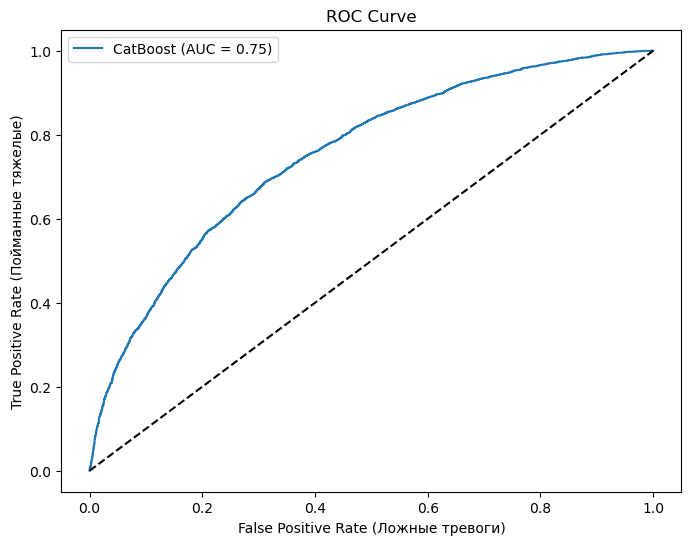

In [84]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Легкий (0)', 'Тяжелый/Смерть (1)']))

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (Ложные тревоги)')
plt.ylabel('True Positive Rate (Пойманные тяжелые)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
feat_importances = model.get_feature_importance(prettified=True)
print(feat_importances.head(15))

Час в категор

Мб по пятнадцатиминуткам